## Analizzo le diverse violenze [quindi le category] per 'by type of offence'

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data=pd.read_csv("./data_cts_violent_and_sexual_crime.csv")
data=data[data["VALUE"]!=0]
data.head(5)

,Iso3_code,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
0,AZE,Azerbaijan,Asia,Western Asia,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,155.0,CTS
1,BEL,Belgium,Europe,Western Europe,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,61959.0,CTS
2,BGR,Bulgaria,Europe,Eastern Europe,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,3806.0,CTS
3,BHR,Bahrain,Asia,Western Asia,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,2701.0,CTS
4,BLR,Belarus,Europe,Eastern Europe,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,4032.0,CTS


In [3]:
dataFiltrato= data[data["Dimension"]=="by type of offence"]

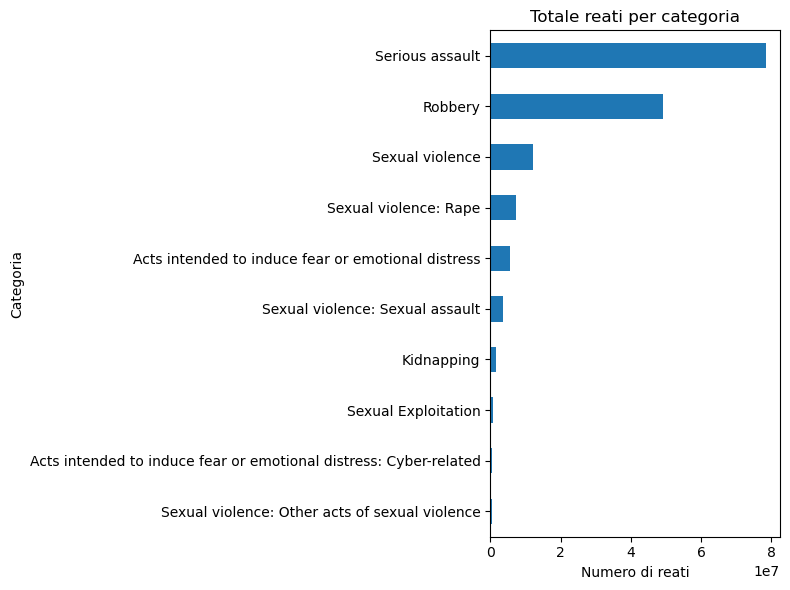

In [6]:
#DISTRIBUZIONE PER CATEGORIA
violenzeCategorie = dataFiltrato[dataFiltrato["Unit of measurement"]=="Counts"].groupby("Category")["VALUE"].sum().sort_values()

fig, ax = plt.subplots(figsize=(8,6))
violenzeCategorie.plot(kind="barh", ax=ax) #riconosce in autonomia gli indici=asse y e i valori=asse x

ax.set_title("Totale reati per categoria")
ax.set_xlabel("Numero di reati")
ax.set_ylabel("Categoria")

plt.tight_layout() #sistema in modo automatico gli spazi nel grafico delle scritte
plt.show()

Ordine dei reati dal più commesso al meno:
- aggressione grave
- rapina
- violenza sessuale
- violenza sessuale: stupro
- atti destinati a indurre paura o disagio emotivo
- violenza sessuale: violenza sessuale
- rapimenti
- sfruttamento sessuale
- atti destinati a indurre paura o disagio emotivo:
- violenza sessuale: altri atti di violenza sessuale

Possiamo dire da questo grafico che la criminalità violenta è dominata da reati fisici diretti (aggressioni e rapine), mentre le altre forme di violenza risultano meno diffuse o semplicemente vengono meno registrate/denunciate.

In [8]:
dataFiltrato["Category"].unique()

array(['Serious assault', 'Kidnapping', 'Sexual violence',
       'Sexual violence: Rape', 'Sexual violence: Sexual assault',
       'Sexual violence: Other acts of sexual violence',
       'Sexual Exploitation',
       'Acts intended to induce fear or emotional distress',
       'Acts intended to induce fear or emotional distress: Cyber-related',
       'Robbery'], dtype=object)

In [9]:
coloreReati={'Serious assault':"#0d1321", 'Kidnapping':"#780000", 'Sexual violence':"#e76f51",
       'Sexual violence: Rape':"#fb6f92", 'Sexual violence: Sexual assault':"#d5bdaf",
       'Sexual violence: Other acts of sexual violence':"#606c38", 'Sexual Exploitation':"#bc6c25",
       'Acts intended to induce fear or emotional distress':"#264653",
       'Acts intended to induce fear or emotional distress: Cyber-related':"#90e0ef", 'Robbery':"#00b4d8"}

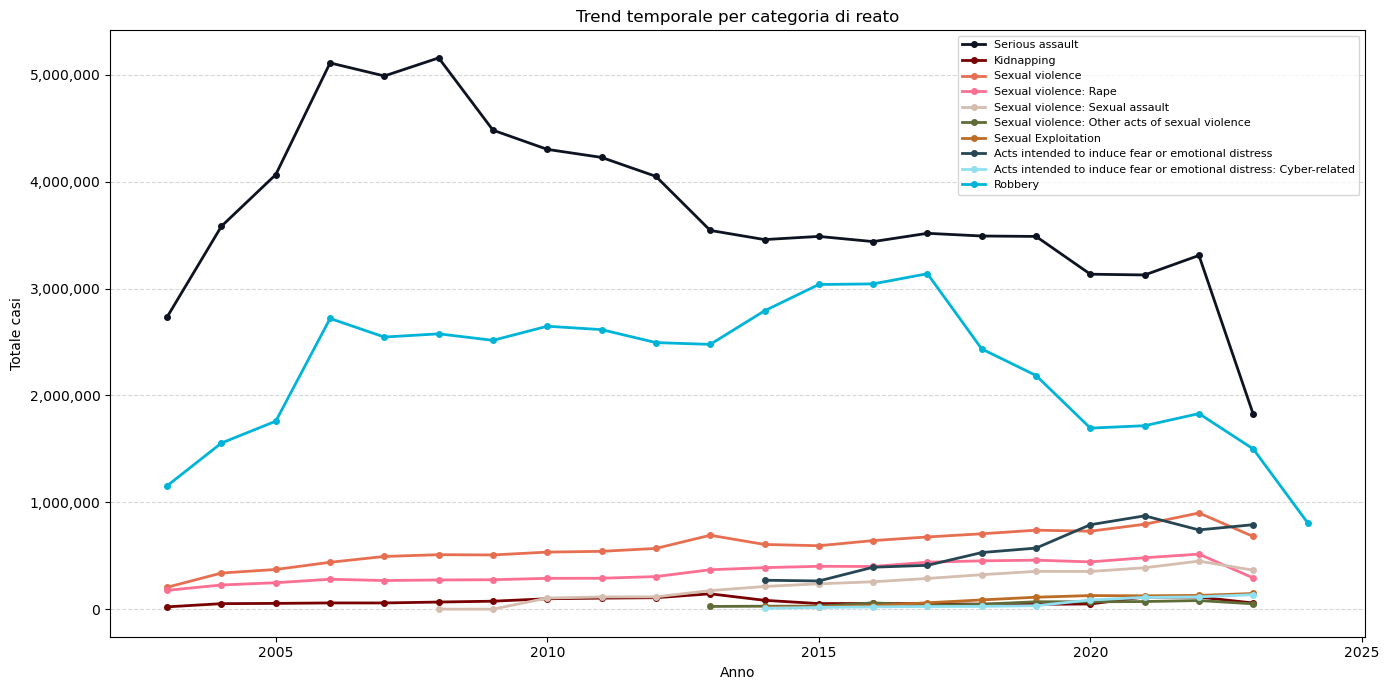

In [10]:
#TREND TEMPORALE PER CATEGORIA
fig, ax = plt.subplots(figsize=(14, 7))

trend = dataFiltrato[dataFiltrato["Unit of measurement"]=="Counts"].groupby(["Year", "Category"])["VALUE"].sum().reset_index()

for cat in dataFiltrato["Category"].unique():
    dati = trend[trend["Category"] == cat]
    ax.plot(dati["Year"], dati["VALUE"], marker="o", linewidth=2, markersize=4, label=cat, color=coloreReati[cat])

ax.set_title("Trend temporale per categoria di reato")
ax.set_xlabel("Anno")
ax.set_ylabel("Totale casi")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}")) #formatta i numeri dell'asse y(come vengono scritti): 1000000 -> 1,000,000
ax.legend(loc="upper right", fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout() #sistema in modo automatico gli spazi nel grafico delle scritte
plt.show()

- l'aggressione grave domina tutte le altre categorie, avendo un picco enorme nel 2006 e 2008
- anche la rapina ha dei valori significativi, ma essa ha il picco maggiore nel 2017
- le categorie di violenze sessuali mostrano un trend in crescita -> non significa unicamente un aumento di reati ma magari solamente di una maggiore denuncia
- gli atti destinati a indurre paura o disagio emotivo mostrano anch'essa una crescita che può esser legata dall'introduzione di nuove leggi che hanno iniziato a classificare e registrare questi comportamenti come reati (in Italia introdotte nel 2009)
- il calo che si nota in praticamente tutte le categorie negli anni 2019-2020 possono essere legati al COVID-19, quindi al lockdown  -> solo gli atti destinati a indurre paura o disagio emotivo salgono in quegli anni

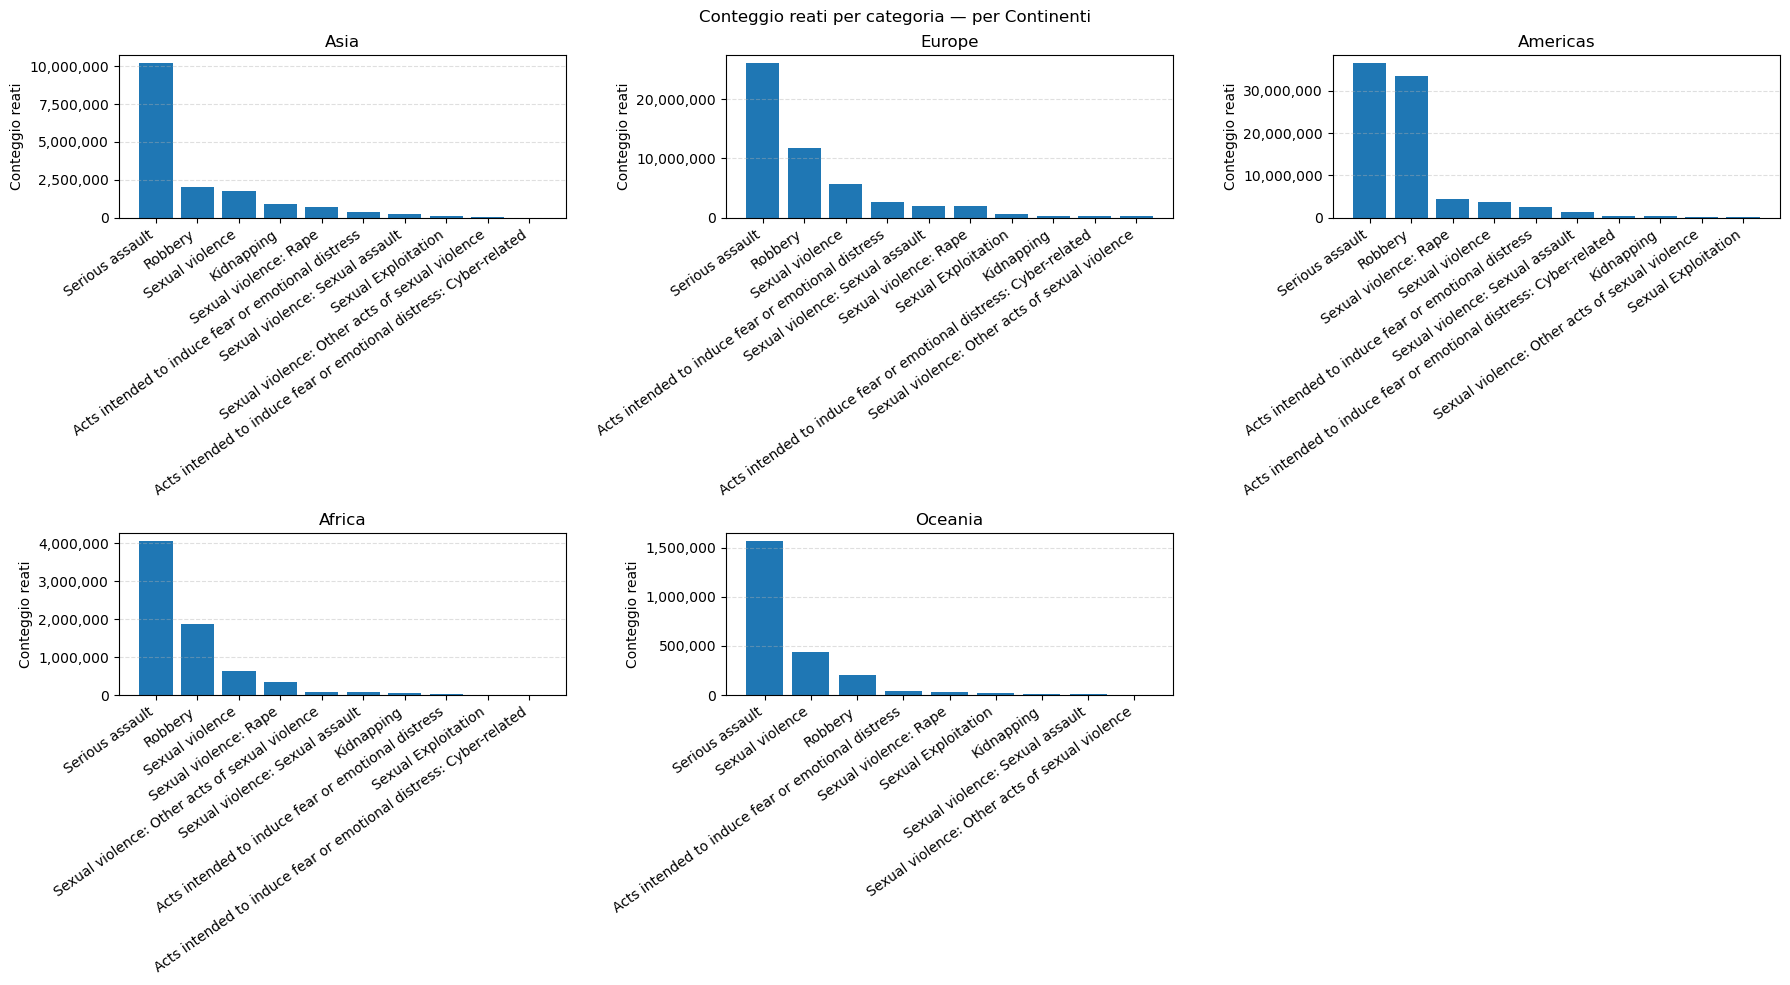

In [12]:
#CONFRONTO TRA REGIONI
continenti= dataFiltrato["Region"].unique()

fig, axs= plt.subplots(2, 3, figsize=(18,10))
axs = axs.flatten() #mi trasforma l'array 2D in una lista 1D, così ci posso accedere con un singolo indice e non più 2

for i, c in enumerate(continenti):
    dati= dataFiltrato[dataFiltrato["Region"]==c]
    somma_cat= dati[dati["Unit of measurement"]=="Counts"].groupby("Category")["VALUE"].sum().sort_values(ascending=False)
    
    axs[i].bar(somma_cat.index, somma_cat.values)
    axs[i].set_title(c)
    axs[i].set_ylabel("Conteggio reati")
    axs[i].set_xticks(range(len(somma_cat.index)))
    axs[i].set_xticklabels(somma_cat.index, rotation=35, ha="right")
    axs[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}")) #formatta i numeri dell'asse y(come vengono scritti): 1000000 -> 1,000,000
    axs[i].grid(axis="y", linestyle="--", alpha=0.4)

# Nasconde il 6° subplot vuoto
axs[5].set_visible(False)

fig.suptitle("Conteggio reati per categoria — per Continenti")
plt.tight_layout() #sistema in modo automatico gli spazi nel grafico delle scritte

plt.show()

- notiamo che in tutti i continenti il reato più commesso è l'aggressione grave
#### America
- è il continente con i valori più alti
- sia l'aggressione grave che la rapina ha valori intorno ai 30 milioni, numri enormi rispetto agli altri continenti -> soprattutto per la rapina che negli altri continenti non è minimamente vicino al valore delle gravi aggressioni

#### Europa 
- ha valori elevati ma più bilanciati

#### Asia
- pur essendo il continente con più popolazione ha dei valori più contenuti -> questo però fa pensare che c'è una mancanza di segnalazione di reati, specialmente considerando che ci son paesi con sistemi di raccolta dati meno sviluppati

#### Africa
- ha un profilo simile all'Asia
- ha, però, le violenze sessuali relativamente più presenti rispetto ad altri continenti

#### Oceania 
- ha volumi bassissimi -> ma suppongo sia una conseguenza che sia il continente con meno popolazione
- interessante, però, che le violenze sessuali superano le rapine, cosa che non succede in nessun altro continente -> può FORSE significare che è presente un sistema di denucia più efficace per questo tipo di reato